#0.Preparação do Ambiente e Dependências

In [ ]:
pip install biopython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 20.5 MB/s eta 0:00:00


In [ ]:
!apt-get update
!apt-get install -y clustalo

Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 https://cli.github.com/packages stable InRelease [3,917 B]
Get:3 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:5 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:7 https://cli.github.com/packages stable/main amd64 Packages [354 B]
Get:8 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [9,606 kB]
Get:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:10 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [2,868 kB]
Get:11 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Hit:12 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:13 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 Packages [1,600 kB]
Get:14 http://securi

In [1]:
#Imports necessarios
from Bio import Entrez, SeqIO, SwissProt
from Bio.SeqRecord import SeqRecord
from Bio.Seq import Seq
from Bio.Blast import NCBIWWW, NCBIXML
from collections import Counter
from io import StringIO
import requests
import subprocess
import re
from Bio import AlignIO, Phylo
from Bio.Phylo.TreeConstruction import DistanceCalculator, DistanceTreeConstructor
import matplotlib.pyplot as plt

# 1.Análise do Fago

Vamos fazer download dos dados oficiais do fago NC_073038.1 diretamente do NCBI em dois formatos, o GenBank e o FASTA.

Obter o genoma do fago

In [2]:
Entrez.email = "alicepicas02@gmail.com"
genome_id = "NC_073038.1"

Formato Genbank

In [3]:
# GenBank
handle = Entrez.efetch(db="nucleotide", id=genome_id, rettype="gb", retmode="text")
record = SeqIO.read(handle, "genbank")
handle.close()

SeqIO.write(record, "AAT1_genome.gb", "genbank")

1

Formato Fasta

In [4]:
# FASTA
handle = Entrez.efetch(db="nucleotide", id=genome_id, rettype="fasta", retmode="text")
record_fasta = SeqIO.read(handle, "fasta")
handle.close()

SeqIO.write(record_fasta, "AAT1_genome.fasta", "fasta")

1

##1.1 Análise do Genoma do Fago

In [5]:
# Análise Geral do Genoma
print(f"Análise Geral do Genoma\n")
print("ID:", record.id)
print("Descrição:", record.description)
print("Tamanho do Genoma:", len(record.seq), "bp")
print("Número de Features:", len(record.features))

Análise Geral do Genoma

ID: NC_073038.1
Descrição: Pseudomonas phage AAT-1, complete genome
Tamanho do Genoma: 57599 bp
Número de Features: 155


In [6]:
# Contagem de Genes
cds_count = 0
for feature in record.features:
    if feature.type == "CDS":
        cds_count += 1

print("Número Total de Genes (CDS):", cds_count)

Número Total de Genes (CDS): 76


In [7]:
# Lista dos Genes e as suas Funções
print(f"Lista dos Genes e as suas Funções\n")
for feature in record.features:
    if feature.type == "CDS":
        locus = feature.qualifiers.get("locus_tag", ["-"])[0]
        product = feature.qualifiers.get("product", ["-"])[0]
        print(locus, "→", product)

Lista dos Genes e as suas Funções

P9A56_gp01 → ribonucleotide reductase of clase II (coenzyme B12 dependent)
P9A56_gp02 → hypothetical protein
P9A56_gp03 → DNA ligase
P9A56_gp04 → structural protein
P9A56_gp05 → putative minor head protein
P9A56_gp06 → hypothetical protein
P9A56_gp07 → hypothetical protein
P9A56_gp08 → virion structural protein
P9A56_gp09 → GTP cyclohydrolase II
P9A56_gp10 → hypothetical protein
P9A56_gp11 → hypothetical protein
P9A56_gp12 → hypothetical protein
P9A56_gp13 → hypothetical protein
P9A56_gp14 → hypothetical protein
P9A56_gp15 → major head protein
P9A56_gp16 → hypothetical protein
P9A56_gp17 → virion structural protein
P9A56_gp18 → virion structural protein
P9A56_gp19 → virion structural protein
P9A56_gp20 → tail terminator protein
P9A56_gp21 → major tail structural protein
P9A56_gp22 → hypothetical protein
P9A56_gp23 → tail tape measure protein
P9A56_gp24 → virion structural protein
P9A56_gp25 → virion structural protein
P9A56_gp26 → virion structural pr

In [8]:
# Organização Geral dos Genes
products = []

for feature in record.features:
    if feature.type == "CDS":
        product = feature.qualifiers.get("product", ["unknown"])[0]
        products.append(product)

counter = Counter(products)

print(f"Organização geral:\n")
for k, v in counter.most_common(10):
    print(k, ":", v)

Organização geral:

hypothetical protein : 42
virion structural protein : 9
terminase large subunit : 2
ribonucleotide reductase of clase II (coenzyme B12 dependent) : 1
DNA ligase : 1
structural protein : 1
putative minor head protein : 1
GTP cyclohydrolase II : 1
major head protein : 1
tail terminator protein : 1


# 2.DNA & PROTAINAS

Vamos isolar as sequências dos genes de interesse e analisar a sequência nucleotidica e proteica

## 2.1 Extrair DNA e PROTEÍNAS


Para cada gene alvo, o código identifica a sua localização, extrai a sequência e guarda-a em ficheiros individuais no formato FASTA.

In [9]:
def processar_genes_genbank(arquivo_gbk, lista_genes):
    record = SeqIO.read(arquivo_gbk, "genbank")

    for gene in lista_genes:
        gene_locus = gene["locus"]
        gene_name = gene["name"]
        found = False

        for feature in record.features:
            if feature.type == "CDS":
                locus = feature.qualifiers.get("locus_tag", [""])[0]
                if locus == gene_locus:
                    found = True
                    start = int(feature.location.start)
                    end = int(feature.location.end)
                    strand = feature.location.strand

                    print("Locus:", gene_locus)
                    print("Nome do Gene:", gene_name)
                    print("Localização:", start, "-", end)
                    print("Cadeia codificante:", "Forward (+)" if strand == 1 else "Reverse (-)")
                    print("="*40)

                    # DNA
                    dna_seq = feature.location.extract(record.seq)
                    print("Comprimento DNA:", len(dna_seq), "bp")
                    dna_record = SeqRecord(dna_seq, id=gene_locus, description=f"DNA sequence of {gene_name}")
                    SeqIO.write(dna_record, f"{gene_locus}_DNA.fasta", "fasta")

                    # Proteína
                    protein_seq = feature.qualifiers["translation"][0]
                    print("Comprimento proteína:", len(protein_seq), "aa")
                    protein_record = SeqRecord(Seq(protein_seq), id=gene_locus, description=f"Protein sequence of {gene_name}")
                    SeqIO.write(protein_record, f"{gene_locus}_protein.fasta", "fasta")

                    print("="*40)
                    print("Qualifiers completos da CDS:")
                    for key, value in feature.qualifiers.items():
                        print(f"{key}: {value}")
                    print("\n\n")


In [10]:
genes_alvo = [
    {"locus": "P9A56_gp33", "name": "endolysin"},
    {"locus": "P9A56_gp34", "name": "putative i-spanin"},
    {"locus": "P9A56_gp35", "name": "putative o-spanin"}
]

processar_genes_genbank("AAT1_genome.gb", genes_alvo)

Locus: P9A56_gp33
Nome do Gene: endolysin
Localização: 30455 - 30956
Cadeia codificante: Forward (+)
Comprimento DNA: 501 bp
Comprimento proteína: 166 aa
Qualifiers completos da CDS:
locus_tag: ['P9A56_gp33']
codon_start: ['1']
transl_table: ['11']
product: ['endolysin']
protein_id: ['YP_010739323.1']
db_xref: ['GeneID:79586709']
translation: ['MTYMLGNKSRQNLQGVHPHLARVVERAIEMTAVDFSVHEGLRTRARQAKLVAAGASQTMDSRHLPSQATGYGHAVDLVPFVDLDGDNRAELRWDWSLCYKVADAVRRASIELNVPIRWGGVWDSALADLAGDLEDEVAEYVARRKAKGKKAFLDGPHFELPASLYP']



Locus: P9A56_gp34
Nome do Gene: putative i-spanin
Localização: 30966 - 31452
Cadeia codificante: Forward (+)
Comprimento DNA: 486 bp
Comprimento proteína: 161 aa
Qualifiers completos da CDS:
locus_tag: ['P9A56_gp34']
codon_start: ['1']
transl_table: ['11']
product: ['putative i-spanin']
protein_id: ['YP_010739324.1']
db_xref: ['GeneID:79586710']
translation: ['MLSLTSLQWKLGAGVLIGVVAVSVIALSYRHYTGLVDSKAELSAQVATLREDVAREKARADSFERAIDRWDQAAKDQAKVLDDFTIAQREAGTYARELLDVLSKHDLGALAKRKPGLI

## 2.2 Análise Proteica

Com as proteínas isoladas, fazemos uma caracterização inicial.

In [11]:
def analisar_composicao_proteina(genes):
    for gene in genes:
        gene_locus = gene["locus"]
        gene_name = gene["name"]

        protein_file = f"{gene_locus}_protein.fasta"
        record = SeqIO.read(protein_file, "fasta")
        protein_seq = str(record.seq)

        # Comprimento
        protein_length = len(protein_seq)
        print(f"Locus: {gene_locus} | Nome: {gene_name}")
        print(f"Comprimento da Proteína: {protein_length} aa")
        print("="*40)

        # Composição de aminoácidos
        aa_count = Counter(protein_seq)
        print("Composição de Aminoácidos:")
        for aa, count in sorted(aa_count.items()):
            print(f"{aa}: {count} ({count/protein_length*100:.1f}%)")
        print("\n" + "-"*40 + "\n")

In [12]:
genes_alvo = [
    {"locus": "P9A56_gp33", "name": "endolysin"},
    {"locus": "P9A56_gp34", "name": "putative i-spanin"},
    {"locus": "P9A56_gp35", "name": "putative o-spanin"}
]

analisar_composicao_proteina(genes_alvo)

Locus: P9A56_gp33 | Nome: endolysin
Comprimento da Proteína: 166 aa
Composição de Aminoácidos:
A: 22 (13.3%)
C: 1 (0.6%)
D: 13 (7.8%)
E: 9 (5.4%)
F: 4 (2.4%)
G: 12 (7.2%)
H: 6 (3.6%)
I: 3 (1.8%)
K: 7 (4.2%)
L: 17 (10.2%)
M: 4 (2.4%)
N: 4 (2.4%)
P: 7 (4.2%)
Q: 5 (3.0%)
R: 14 (8.4%)
S: 9 (5.4%)
T: 5 (3.0%)
V: 15 (9.0%)
W: 4 (2.4%)
Y: 5 (3.0%)

----------------------------------------

Locus: P9A56_gp34 | Nome: putative i-spanin
Comprimento da Proteína: 161 aa
Composição de Aminoácidos:
A: 29 (18.0%)
D: 12 (7.5%)
E: 8 (5.0%)
F: 2 (1.2%)
G: 13 (8.1%)
H: 2 (1.2%)
I: 6 (3.7%)
K: 8 (5.0%)
L: 19 (11.8%)
M: 1 (0.6%)
N: 2 (1.2%)
P: 3 (1.9%)
Q: 7 (4.3%)
R: 15 (9.3%)
S: 9 (5.6%)
T: 9 (5.6%)
V: 11 (6.8%)
W: 2 (1.2%)
Y: 3 (1.9%)

----------------------------------------

Locus: P9A56_gp35 | Nome: putative o-spanin
Comprimento da Proteína: 120 aa
Composição de Aminoácidos:
A: 16 (13.3%)
C: 2 (1.7%)
D: 2 (1.7%)
E: 9 (7.5%)
F: 3 (2.5%)
G: 5 (4.2%)
I: 1 (0.8%)
K: 5 (4.2%)
L: 10 (8.3%)
M: 2 (1.7%)
N: 1 (

# 3.BLAST

Nesta etapa, vamos fazer um BLASTp entre as nossas proteínas e as sequências já conhecidas e depositadas em bases de dados públicas.

## 3.1 BLASTp da proteína

In [13]:
proteins = [
    "P9A56_gp33_protein.fasta",
    "P9A56_gp34_protein.fasta",
    "P9A56_gp35_protein.fasta"
]

Faz o blastP das protainas

In [14]:
for protein_file in proteins:
        record = SeqIO.read(protein_file, "fasta")
        result_handle = NCBIWWW.qblast("blastp", "nr", record.seq)

        xml_file = protein_file.replace("_protein.fasta", "_blast.xml")
        with open(xml_file, "w") as out_handle:
            out_handle.write(result_handle.read())
        result_handle.close()


Lê os resultados do blast, seleciona aos 10 melhores e filtra o e value

In [15]:
def analisar_resultados_blast(blast_files):
    for blast_file in blast_files:

        with open(blast_file) as result_handle:
            blast_records = NCBIXML.parse(result_handle)

            homologs_info = []
            funcoes = []

            for blast_record in blast_records:
                print("="*100)
                print(f"\nQuery: {blast_record.query}")
                print("Homólogos significativos:")

                for alignment in blast_record.alignments[:10]:
                    for hsp in alignment.hsps:
                        if hsp.expect < 1e-5 and hsp.identities / hsp.align_length >= 0.3:
                            print(f"Hit: {alignment.title}")
                            print(f"E-value: {hsp.expect}")
                            print(f"Identidade: {hsp.identities}/{hsp.align_length} ({hsp.identities/hsp.align_length*100:.1f}%)")
                            print("="*40)

                            homologs_info.append({
                                "title": alignment.title,
                                "e_value": hsp.expect,
                                "identidade": hsp.identities,
                                "align_length": hsp.align_length
                            })

                            if "[" in alignment.title:
                                func = alignment.title.split("[")[0].strip()
                            else:
                                func = alignment.title
                            funcoes.append(func)
                            break

        contagem_funcoes = Counter(funcoes)
        print("\nFunções Mais Frequentes entre os Homólogos Significativos:")
        for func, count in contagem_funcoes.most_common(10):
            print(f"{func}: {count}")

In [16]:
blast_files = [
    "P9A56_gp33_blast.xml",
    "P9A56_gp34_blast.xml",
    "P9A56_gp35_blast.xml"
]

analisar_resultados_blast(blast_files)


Query: unnamed protein product
Homólogos significativos:
Hit: ref|YP_010739261.1| endolysin [Pseudomonas phage phiH2] >ref|YP_010739323.1| endolysin [Pseudomonas phage AAT-1] >ref|YP_010739414.1| endolysin [Pseudomonas phage phiH1] >gb|WGH15499.1| putative endolysin [Pseudomonas phage PA_LZ02] >gb|AME18059.1| endolysin [Pseudomonas phage AAT-1] >gb|UXX42079.1| endolysin [Pseudomonas phage phiH2] >gb|UYD21614.1| endolysin [Pseudomonas phage phiH1]
E-value: 5.30913e-118
Identidade: 166/166 (100.0%)
Hit: ref|YP_009210649.1| endolysin [Pseudomonas phage PaMx28] >gb|ALH23637.1| putative endolysin [Pseudomonas phage PaMx28]
E-value: 5.11113e-102
Identidade: 144/166 (86.7%)
Hit: ref|YP_009199477.1| endolysin [Pseudomonas phage PaMx74] >gb|ALH23507.1| putative endolysin [Pseudomonas phage PaMx74]
E-value: 6.77319e-93
Identidade: 134/165 (81.2%)
Hit: ref|YP_010738480.1| endolysin [Stenotrophomonas phage vB_Sm_QDWS359] >gb|UQM93921.1| endolysin [Stenotrophomonas phage vB_Sm_QDWS359]
E-value: 2.

# 4.Analise das PROTEÍNAS

Nesta fase, cruzamos as sequências obtidas com bases de dados de referência para confirmar as suas funções e identificar regiões estruturais importantes.

## 4.1 Analise de domínios conservados (CDD) da proteina

In [17]:
def obter_uniprot(uniprot_ids):
    for uniprot_id in uniprot_ids:
        # Busca o arquivo FASTA
        fasta_url = f"https://www.uniprot.org/uniprotkb/{uniprot_id}.fasta?format=fasta"
        r = requests.get(fasta_url)

        if r.status_code == 200:
            fasta_file = f"{uniprot_id}.fasta"
            with open(fasta_file, "w") as f:
                f.write(r.text)

            record = SeqIO.read(fasta_file, "fasta")
            protein_seq = str(record.seq)
            print(f"ID: {record.id}")
            print(f"Comprimento: {len(protein_seq)} aa")
            print("="*40)


        # Busca os detalhes via SwissProt (formato TXT)
        txt_url = f"https://rest.uniprot.org/uniprotkb/{uniprot_id}.txt"
        r = requests.get(txt_url)

        if r.status_code == 200:
            record_sp = SwissProt.read(StringIO(r.text))

            print("Entry Name:", record_sp.entry_name)
            print("Organismo:", record_sp.organism)
            print("Comprimento:", record_sp.sequence_length)
            print("Curation Status:", record_sp.data_class)

            print("\nDescrição/Função:")
            for desc in record_sp.description.split(";"):
                print("-", desc.strip())
            print("\n" + "="*40 + "\n")

In [18]:
uniprot_ids = ["A0A125SA63", "A0A125SA64", "A0A193DRX6"]
obter_uniprot(uniprot_ids)

ID: tr|A0A125SA63|A0A125SA63_9CAUD
Comprimento: 166 aa
Entry Name: A0A125SA63_9CAUD
Organismo: Pseudomonas phage AAT-1.
Comprimento: 166
Curation Status: Unreviewed

Descrição/Função:
- SubName: Full=Endolysin {ECO:0000313|EMBL:AME18059.1}
- 


ID: tr|A0A125SA64|A0A125SA64_9CAUD
Comprimento: 161 aa
Entry Name: A0A125SA64_9CAUD
Organismo: Pseudomonas phage AAT-1.
Comprimento: 161
Curation Status: Unreviewed

Descrição/Função:
- SubName: Full=I-spanin {ECO:0000313|EMBL:AME18060.1}
- 


ID: tr|A0A193DRX6|A0A193DRX6_9CAUD
Comprimento: 120 aa
Entry Name: A0A193DRX6_9CAUD
Organismo: Pseudomonas phage AAT-1.
Comprimento: 120
Curation Status: Unreviewed

Descrição/Função:
- SubName: Full=O-spanin {ECO:0000313|EMBL:ANN44564.1}
- 




## 4.2 Extrair domínios conservados via CDD

In [19]:
def analisar_dominios_cdd(genes):
    for gene in genes:
        protein_record = SeqIO.read(gene["fasta"], "fasta")
        protein_seq_str = str(protein_record.seq)

        url = "https://www.ncbi.nlm.nih.gov/Structure/bwrpsb/bwrpsb.cgi"
        params = {
            "seq": protein_seq_str,
            "db": "cdd",
            "smode": "auto",
            "output": "text"
        }

        r = requests.post(url, data=params)
        if r.status_code == 200:
            with open(f"{gene['locus']}_cdd.txt", "w", encoding="utf-8") as f:
                f.write(r.text)

In [20]:
genes = [
    {"locus": "P9A56_gp33", "name": "endolysin", "fasta": "P9A56_gp33_protein.fasta"},
    {"locus": "P9A56_gp34", "name": "putative i-spanin", "fasta": "P9A56_gp34_protein.fasta"},
    {"locus": "P9A56_gp35", "name": "putative o-spanin", "fasta": "P9A56_gp35_protein.fasta"}
]

analisar_dominios_cdd(genes)

## 4.3 Extração das Informações Relevantes de CDD

In [21]:
def ler_dominios_cdd(genes):
    for gene in genes:
        cdd_file = f"{gene['locus']}_cdd.txt"
        print(f"\n=== Domínios Conservados (CDD) para {gene['locus']} ===\n")

        with open(cdd_file, encoding="utf-8") as f:
            lines = f.readlines()

        for line in lines:
            if "cd" in line.lower() and "e-value" in line.lower():
                print(line.strip())


In [22]:
genes = [
    {"locus": "P9A56_gp33"},
    {"locus": "P9A56_gp34"},
    {"locus": "P9A56_gp35"}
]

ler_dominios_cdd(genes)


=== Domínios Conservados (CDD) para P9A56_gp33 ===

'content': 'The Full display <b>shows all domain models</b>, as available for each region on the query sequence, that meet or exceed the RPS-BLAST threshold for statistical significance (i.e., the <a href="/Structure/cdd/cdd_help.shtml#WRPSBExpect">E-value cutoff</a>).  The <a href="/Structure/cdd/cdd_help.shtml#RPSB_hit_types">hit types</a> can include <a href="/Structure/cdd/cdd_help.shtml#RPSB_hit_type_specific_hit">specific hits</a>, <a href="/Structure/cdd/cdd_help.shtml#RPSB_hit_type_non_specific_hit">non-specific hits</a>, the <a href="/Structure/cdd/cdd_help.shtml#RPSB_hit_type_superfamily">superfamily(ies)</a> to which those hits belong, and <a href="/Structure/cdd/cdd_help.shtml#RPSB_hit_type_multi_domain">multi-domain models</a>.<br>The bottom of the Full Display also summarizes <b>BLAST search parameters</b>, which include a summary of information such as the <a href="/Structure/cdd/cdd_help.shtml#RPSBSearchDb">database w

#5.Alinhamento Multiplo

In [23]:
def extrair_sequencias_proteicas(genbank_file, genes):
    record = SeqIO.read(genbank_file, "genbank")
    gene_sequences = {}

    for gene in genes:
        gene_locus = gene["locus"]
        for feature in record.features:
            if feature.type == "CDS":
                locus_tag = feature.qualifiers.get("locus_tag", [""])[0]
                if locus_tag == gene_locus:
                    protein_seq = feature.qualifiers.get("translation", [""])[0]
                    if protein_seq:
                        gene_sequences[gene_locus] = protein_seq

    return gene_sequences

In [24]:
def obter_homologos(xml_file, email):
    Entrez.email = email
    lista_final = []
    
    with open(xml_file) as result_handle:
        blast_records = NCBIXML.parse(result_handle)
  
        for record in blast_records:
            for alignment in record.alignments[1:11]: 
                for hsp in alignment.hsps:
                    if hsp.expect < 1e-5 and (hsp.identities / hsp.align_length) >= 0.3:
                        accession_id = alignment.accession
                        nome_fago = "Desconhecido"
                        if "[" in alignment.title:
                            nome_fago = alignment.title.split("[")[-1].split("]")[0].replace(" ", "_")
                        try:
                            handle = Entrez.efetch(db="protein", id=accession_id, rettype="fasta", retmode="text")
                            seq_record = SeqIO.read(handle, "fasta")
                            handle.close()
                            lista_final.append((nome_fago, str(seq_record.seq)))
                        except Exception as e:
                            print(f"Erro ao baixar {accession_id}: {e}")
                            continue
                        break 
    return lista_final

In [25]:
def gerar_fasta_homologos(gene_sequences, homologos):
    for gene_id, seq in gene_sequences.items():
        homologs_list = [(gene_id, seq)] + homologos

        records = []
        seen = {}

        for name, s in homologs_list:
            clean_name = name.replace(" ", "_").replace("[", "").replace("]", "")

            if clean_name in seen:
                seen[clean_name] += 1
                clean_name = f"{clean_name}_{seen[clean_name]}"
            else:
                seen[clean_name] = 1

            records.append(SeqRecord(Seq(s), id=clean_name, description=""))

        fasta_file = f"{gene_id}_homologs.fasta"
        SeqIO.write(records, fasta_file, "fasta")
        print(f"FASTA gerado: {fasta_file}")

In [26]:
def alinhar_fasta_clustalo(fasta_files):
    for fasta_file in fasta_files:
        aligned_file = fasta_file.replace("_homologs.fasta", "_aligned.fasta")
        cmd = [
            "clustalo",
            "-i", fasta_file,
            "-o", aligned_file,
            "--force",
            "--verbose"
        ]

        subprocess.run(cmd, check=True)
        print(f"Alinhamento múltiplo gerado: {aligned_file}")

## 5.1 Endolisina

In [27]:
genes = [{"locus": "P9A56_gp33", "name": "endolysin"}]
genbank_file = "AAT1_genome.gb"

gene_sequences = extrair_sequencias_proteicas(genbank_file, genes)
print(gene_sequences)

{'P9A56_gp33': 'MTYMLGNKSRQNLQGVHPHLARVVERAIEMTAVDFSVHEGLRTRARQAKLVAAGASQTMDSRHLPSQATGYGHAVDLVPFVDLDGDNRAELRWDWSLCYKVADAVRRASIELNVPIRWGGVWDSALADLAGDLEDEVAEYVARRKAKGKKAFLDGPHFELPASLYP'}


In [28]:
email = "eduardasantos6789@gmail.com"
homologos = obter_homologos("P9A56_gp33_blast.xml", email)

for h in homologos:
    print(h)

('Pseudomonas_phage_PaMx28', 'MSYVLGNKSRQNLQGVHPHLVRVVERAIELTAVDFSVHEGLRTRARQAKLVAAGASQTMDSRHLAGGPTGYGHAVDLVPFVDFDGDGRSELRWDWSLCYRVAEAVRRASIELKVPIRWGGVWDRTLADLGDDLEDEVAGYVARRKAQGKKAFLDGPHFELPSSVYP')
('Pseudomonas_phage_PaMx74', 'MTTFALGSKSRQSLSGVHPDLVRVVERAIEVTPVDFQVYEGLRTRARQAKLVASGASQTMDSRHLPGADGLGHAVDLVPLIDFDGDGKAELRWDWNLCYKVADAVRRASMELQVPIRWGGVWDQTLADLAGDMDDEVAGYVARRKAAGKKAFLDGPHFELPASIYP')
('Stenotrophomonas_phage_vB_Sm_QDWS359', 'MTFALGSKSRTNLQGVHPDLVRVVERAIELTGVDFQVFEGLRTRARQAKLVAAGASQTMDSRHLPGRDGLGHAVDLVPLIDFDKDGRAELRWDWSLCYRVALAMRAASIELQVPIRWGGVWDRALADLADPEDEVAEYVARRKAQGKKAFLDGPHFELPASIYP')
('Xanthomonas_phage_Xoo-sp2', 'MTFALGSKSRTNLQGVHPHLVQVVERAIQVTSVDFQVFEGLRTRQRQAKLVAQGASQTMDSRHLPGRDGLGHAVDLVPLIDFDQDGRAELRWDWSLCYKVALAVRVASIELQVPIRWGGVWDRALADLADPEDEVAEYVVRRKAIGKKAFLDGPHFELPASVYP')
('Xanthomonas_phage_MET13-T1', 'MSFVLGTKSRASLRGVHPHLVKVVERAIQLTGVDFQVYEGLRTRERQATLVARGASQTMDSRHLPGRDGLGHAVDLVPLIDFDGDGKAELRWDWSLCYKVAMAVRQASLELNVPIRWGGVWDRALADLADPEDEVAEYVGRRKAMGKKAFLDGPHFELPANIY

In [29]:
gerar_fasta_homologos(gene_sequences, homologos)

FASTA gerado: P9A56_gp33_homologs.fasta


In [ ]:
fasta_files = ["P9A56_gp33_homologs.fasta"]

alinhar_fasta_clustalo(fasta_files)

In [ ]:
aligned_files = [
    "P9A56_gp33_aligned.fasta"
]

for alinhamento in aligned_files:
  alignment = AlignIO.read(alinhamento, "fasta")
  print(alignment)

Alignment with 10 rows and 167 columns
-MTYMLGNKSRQNLQGVHPHLARVVERAIEMTAVDFSVHEGLRT...LYP P9A56_gp33
-MSYVLGNKSRQNLQGVHPHLVRVVERAIELTAVDFSVHEGLRT...VYP Pseudomonas_phage_PaMx28
MTTFALGSKSRQSLSGVHPDLVRVVERAIEVTPVDFQVYEGLRT...IYP Pseudomonas_phage_PaMx74
-MTFALGSKSRTNLQGVHPDLVRVVERAIELTGVDFQVFEGLRT...IYP Stenotrophomonas_phage_vB_Sm_QDWS359
-MTFALGSKSRTNLQGVHPHLVQVVERAIQVTSVDFQVFEGLRT...VYP Xanthomonas_phage_Xoo-sp2
-MSFVLGTKSRASLRGVHPHLVKVVERAIQLTGVDFQVYEGLRT...IYP Xanthomonas_phage_MET13-T1
-MSFALGTKSRASLRGVHPHLVKVVERAIQLTGVDFQVYEGLRT...IYP Xanthomonas_phage_Xp12
-MSFVLGTKSRANLRGVHPQLVKVVERAIQVTSVDFQVFEGLRT...IYP Xanthomonas_phage_FMYAK-P1
-MSFALGTKSRASLRGVHPHLVKVVERAIQLTGVDFQVYEGLRT...IYP Xanthomonas_phage_vB_XeuM-YB23
-MSFVLGTKSRSSLRGVHPHLVKVVERAIQVTSVDFQVYEGLRT...NYP Stenotrophomonas_phage_DLP4


## 5.2 I-Spanina

In [31]:
genes = [{"locus": "P9A56_gp34", "name": "i-spanin"}]
genbank_file = "AAT1_genome.gb"

gene_sequences = extrair_sequencias_proteicas(genbank_file, genes)

print(gene_sequences)

{'P9A56_gp34': 'MLSLTSLQWKLGAGVLIGVVAVSVIALSYRHYTGLVDSKAELSAQVATLREDVAREKARADSFERAIDRWDQAAKDQAKVLDDFTIAQREAGTYARELLDVLSKHDLGALAKRKPGLIENRINAGSADALRLLERATQGPAVDGGQGATAAGTATPRARAR'}


In [32]:
email = "eduardasantos6789@gmail.com"
homologos = obter_homologos("P9A56_gp34_blast.xml", email)

for h in homologos:
    print(h)

('Pseudomonas_phage_PA_LZ02', 'MLSLTSLQWKLGAGVLIGVVAVSVIALSYRHYTGLVDSKAELSAQVATLREDVAREKARADSFERAIDRWDQAAKDQAKALDDFTIAQREAGTYARELLDVLSKHDLGALAKRKPGLIENRINAGSADALRLLERATQGPTVDGGQGAAAAGATASGARAR')
('Pseudomonas_phage_phiH2', 'MLSLTSLQWKLGAGVLIGVVAVSVIALSYRHYTGLVDSKAELSAQVATLREDVAREKARADSFERAIDRWDQAAKDQAKALDDFTIAQREAGTYARELLDVLSKHDLGALAKRKPGLIENRINAGSADALRLLERATQGPTVDGDQGAAAAGATTSGARAR')
('Pseudomonas_phage_phiH1', 'MLSLTSLQWKLGAGVLIGVVAVSVIALSYRHYTGLVDSKAELSAQVATLREDVAREKARADSFERAIDRWDQAAKDQAKALDDFTIAQREAGTYARELLDVLSKHDLGALAKRKPGLIENRINAGSADALRLLERATQGATVDGGQGAAAAGAAASGARAR')
('Pseudomonas_phage_PaMx28', 'MLNLTGLQWKIGAGILIGVATVTVIALSYRHYTGLVDAKAELSAQVATLREDVAREKSRADALSSAVDRWDQAAREQARALDQLTTAQREAGTYARELRDVLSKHDLGALAKRKPGLIENRINAGTADALRLLERSTEGAAAAERQGATAPRTATPRARQD')
('Xanthomonas_phage_Xoo-sp2', 'MIPLGYKIGAGVLIGVALVTAIALSYRHYTGLVDDKATLTEQVGTLKQDVAREKARADAFKLTIDKWDEAAAKQAEALDRFSTAQREAGETTRKLTDVLSKHDLGALARSKPGLIQTRINAGTADAFRLLEQSTGAAPTGGAQAAPAARPAQAPARKD')
('Pseudomonas_phage_PaMx74', 'MFD

In [33]:
gerar_fasta_homologos(gene_sequences, homologos)

FASTA gerado: P9A56_gp34_homologs.fasta


In [ ]:
fasta_files = ["P9A56_gp34_homologs.fasta"]

alinhar_fasta_clustalo(fasta_files)

Alinhamento múltiplo gerado: P9A56_gp34_aligned.fasta


In [ ]:
from Bio import AlignIO
aligned_files = [
    "P9A56_gp34_aligned.fasta"
]

for alinhamento in aligned_files:
  alignment = AlignIO.read(alinhamento, "fasta")
  print(alignment)

Alignment with 10 rows and 162 columns
MLSLTSLQWK-LGAGVLIGVVAVSVIALSYRHYTGLVDSKAELS...RAR P9A56_gp34
MLSLTSLQWK-LGAGVLIGVVAVSVIALSYRHYTGLVDSKAELS...RAR Pseudomonas_phage_PA_LZ02
MLSLTSLQWK-LGAGVLIGVVAVSVIALSYRHYTGLVDSKAELS...RAR Pseudomonas_phage_phiH2
MLSLTSLQWK-LGAGVLIGVVAVSVIALSYRHYTGLVDSKAELS...RAR Pseudomonas_phage_phiH1
MLNLTGLQWK-IGAGILIGVATVTVIALSYRHYTGLVDAKAELS...RQD Pseudomonas_phage_PaMx28
---MIPLGYK-IGAGVLIGVALVTAIALSYRHYTGLVDDKATLT...RKD Xanthomonas_phage_Xoo-sp2
---MFDLGLK-AYVGIAIGVAVTAAVALSYRHYSGLVESNAQLT...--- Pseudomonas_phage_PaMx74
---MIPLGYK-IGAGVLIGVALVTAIALSYRHYTGLVDDKAKLT...RKD Stenotrophomonas_phage_vB_Sm_QDWS359
---MIAINWTKVGIWAAIVAASATAVFLGYRHYNGLVEAKVELS...R-- Xanthomonas_phage_Mallos
----MLLGYK-IGAGVLIGVALVTTIALSYRHYDGLVQDKADLT...RKD Xanthomonas_phage_Elanor


## 5.3 O-Spanin

In [34]:
genes = [{"locus": "P9A56_gp35", "name": "o-spanin"}]
genbank_file = "AAT1_genome.gb"

gene_sequences = extrair_sequencias_proteicas(genbank_file, genes)

print(gene_sequences)

{'P9A56_gp35': 'MFYPSTTSARSPSASRVSSKIALTLAALTLCACSSVPPKAQPSTGAKEPPLPVLPRPEPVRVEQVKWQVVEVDGEPLFALTARGYEALSRNVSEMVRWAQEASWQLDFYRRGRAAGEASK'}


In [35]:
email = "eduardasantos6789@gmail.com"
homologos = obter_homologos("P9A56_gp35_blast.xml", email)

for h in homologos:
    print(h)

('Stenotrophomonas_phage_vB_SmaS-AXL_1', 'MSYPSTTSARSPGASRVSYSLASMLALLMLSACSSNPPAAQPPVEAKQPPLPVLPKPQPVRTESVEWRVVQVDGESFFAVTARGYEALSRNLADTIRWAKEASWQLDFYRDSRQPAEPQGDSK')
('Xanthomonas_phage_vB_Xar_IVIA-DoCa10', 'MSYPSTTSARSPGASRVSYSLASMLALLMLSACSSNPPVAQPPVEAKQPPLPVLPKPQPVRTESVEWRVVQVDGESFFAVTARGYEALSRNLADTIRWAKEASWQLDFYRDSRQPAEPQGDSK')
('Stenotrophomonas_phage_DLP4', 'MSYPSTTSARSPGASRVSYSLASMLALLTLSACSSNPPVAQPPVEAKQPPPPVLPKPQPVRTESVEWRVVQVDGESLFAVTARGYEALSRNLADTIRWAKEASWQLDFYRDSRQPADDPKGESK')
('Pseudomonas_phage_PA_LZ02', 'MRVEQVKWQVVEVDGEPLFALTARGYEAMSRNVSEMVRWAQEASWQLDFYRRGRAAGEASK')
('Stenotrophomonas_phage_A1432', 'MVLPPEEHKQPPLPVLPKPQPVRTETVKWQVVQVNGESLFAVTAQGYEALARNLAETIRWAKEASWQLDFYRETRQSAETQGDKK')
('Xanthomonas_phage_Xp12', 'MDPPAEPKQPPLPVLPKPQPVRTESVQWRLVQVDGETLFAVTARGYESLSRNLAETIRWAKEASWQLDFYRDSRQTDKPQGESK')
('Pseudomonas_phage_PaMx74', 'MLPAPEPVKLETVRWQVVEVGGESAFALTARGYEALSRNLAEMARWAKEASYQLDFYRRRTAPAQADDGKGGK')
('Pseudomonas_phage_KPP23', 'MTSILSQGKNRVLSKIGLILVPLALCACSNVKPAEIA

In [36]:
gerar_fasta_homologos(gene_sequences, homologos)

FASTA gerado: P9A56_gp35_homologs.fasta


In [ ]:
fasta_files = ["P9A56_gp35_homologs.fasta"]

alinhar_fasta_clustalo(fasta_files)

Alinhamento múltiplo gerado: P9A56_gp35_aligned.fasta


In [ ]:
aligned_files = [
    "P9A56_gp35_aligned.fasta"
]

for alinhamento in aligned_files:
  alignment = AlignIO.read(alinhamento, "fasta")
  print(alignment)

Alignment with 9 rows and 128 columns
MFYPSTTSARSPSASRVSSKIALTLAALTLCACSSVPPKAQPST...--- P9A56_gp35
MSYPSTTSARSPGASRVSYSLASMLALLMLSACSSNPPAAQPPV...--- Stenotrophomonas_phage_vB_SmaS-AXL_1
MSYPSTTSARSPGASRVSYSLASMLALLMLSACSSNPPVAQPPV...--- Xanthomonas_phage_vB_Xar_IVIA-DoCa6
MSYPSTTSARSPGASRVSYSLASMLALLTLSACSSNPPVAQPPV...--- Stenotrophomonas_phage_DLP4
--------------------------------------------...--- Pseudomonas_phage_PA_LZ02
--------------------------------------MVLPPE...--- Stenotrophomonas_phage_A1432
---------------------------------------MDPPA...--- Xanthomonas_phage_Xp12
--------------------------------------------...--- Pseudomonas_phage_PaMx74
--------------------------------------------...DSK Xanthomonas_phage_Mallos


# 6.Árvores Filogenéticas

Utilizamos o método Neighbor-Joining para a construção das árvores filogenéticas

In [ ]:
def gerar_arvores_filo(aligned_files, figsize=(10, 8)):
    for aligned_file in aligned_files:
        alignment = AlignIO.read(aligned_file, "fasta")

        calculator = DistanceCalculator('identity')
        dm = calculator.get_distance(alignment)

        constructor = DistanceTreeConstructor()
        tree = constructor.nj(dm)

        tree_file = aligned_file.replace("_aligned.fasta", "_tree.xml")
        Phylo.write(tree, tree_file, "phyloxml")
        print(f"Árvore filogenética gerada: {tree_file}")

        fig = plt.figure(figsize=figsize)
        axes = fig.add_subplot(1, 1, 1)
        Phylo.draw(tree, axes=axes, do_show=True,
                   label_func=lambda x: x.name if x.is_terminal() else "")

## 6.1 Endolisina

Árvore filogenética gerada: P9A56_gp33_tree.xml


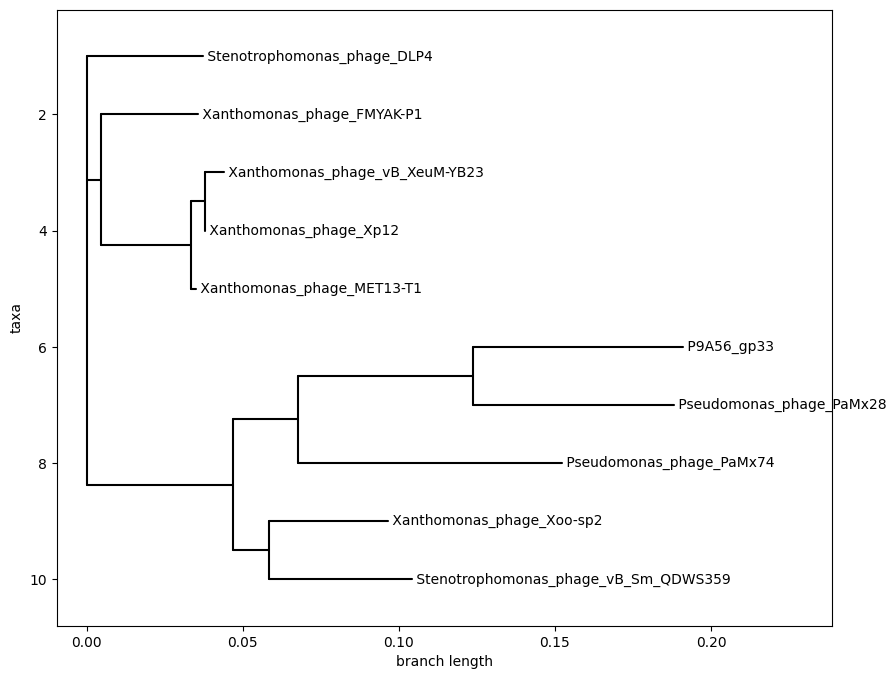

In [ ]:
aligned_files = ["P9A56_gp33_aligned.fasta"]

gerar_arvores_filo(aligned_files)

## 6.2 I-Spanin

Árvore filogenética gerada: P9A56_gp34_tree.xml


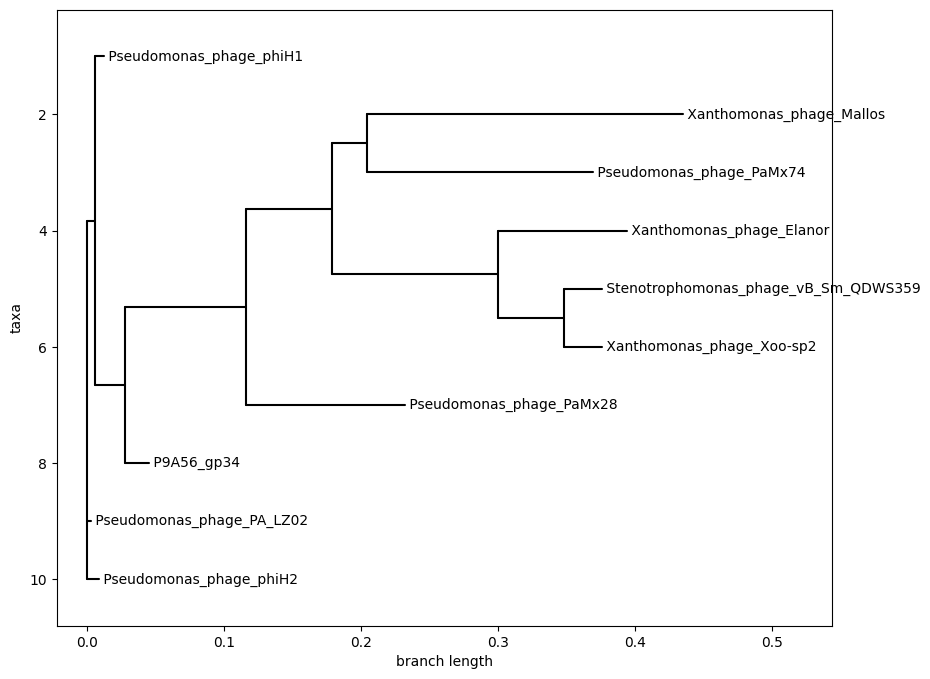

In [ ]:
aligned_files = ["P9A56_gp34_aligned.fasta"]

gerar_arvores_filo(aligned_files)

## 6.2 O-Spanin

Árvore filogenética gerada: P9A56_gp35_tree.xml


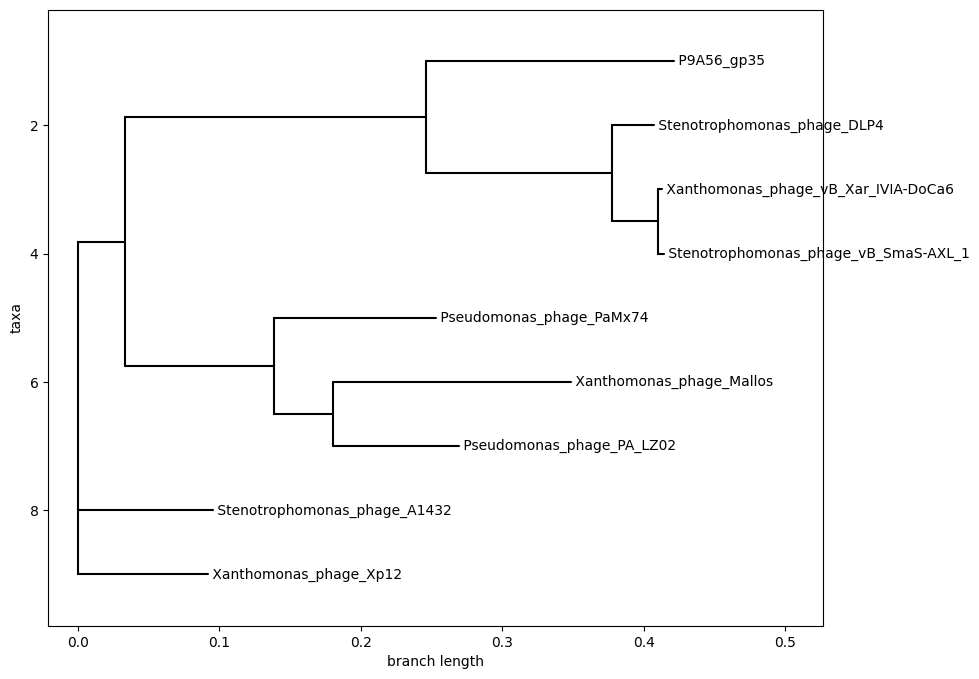

In [ ]:
aligned_files = ["P9A56_gp35_aligned.fasta"]

gerar_arvores_filo(aligned_files)